In [1]:
from tdc.single_pred import ADME
from tdc.single_pred import Tox

# Solubility AqSolDB dataset
# predicts the solubility of a compound in water
solubility = ADME(name = 'Solubility_AqSolDB')
solubility_split = solubility.get_split()

# BBB permeability dataset
# predicts whether a compound can cross the blood-brain barrier (BBB)
BBB = ADME(name = 'BBB_Martins')
BBB_split = BBB.get_split()

# hERG blockade dataset
# predicts cardiotoxicity risk
hERG = Tox(name = 'hERG')
hERG_split = hERG.get_split()

# CYP3A4 inhibition dataset
# predicts drug-drug interaction risk via metabolism by CYP3A4 enzyme
CYP3A4 = ADME(name = 'CYP3A4_Veith')
CYP3A4_split = CYP3A4.get_split()

# Clearance Hepatocyte AZ dataset
# how fast the body eliminates the compound via liver metabolism
clearance = ADME(name = 'Clearance_Hepatocyte_AZ')
clearance_split = clearance.get_split()



Found local copy...


Loading...


Done!


Found local copy...


Loading...


...

Loading...


Done!


Found local copy...


Loading...


Done!


## 1. Solubility (AqSolDB) — EDA

Predicts aqueous solubility (log solubility, mol/L) of a compound — a regression task. Affects formulation and bioavailability.

In [2]:
solubility_split['train'].head()

,Drug_ID,Drug,Y
0,Benzo[cd]indol-2(1H)-one,O=C1Nc2cccc3cccc1c23,-3.254767
1,4-chlorobenzaldehyde,O=Cc1ccc(Cl)cc1,-2.177078
2,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,c1cc(N(CC2CO2)CC2CO2)ccc1Cc1ccc(N(CC2CO2)CC2CO...,-4.662065
3,vinyltoluene,C=Cc1cccc(C)c1,-3.123150
4,3-(3-ethylcyclopentyl)propanoic acid,CCC1CCC(CCC(=O)O)C1,-3.286116


In [3]:
# How many compounds?
for name, df in solubility_split.items():
    print(f"{name}: {df.shape[0]} compounds, {df.shape[1]} columns")

total = sum(df.shape[0] for df in solubility_split.values())
print(f"\ntotal: {total} compounds")

train: 6988 compounds, 3 columns
valid: 998 compounds, 3 columns
test: 1996 compounds, 3 columns

total: 9982 compounds


In [4]:
# Any missing data?
for name, df in solubility_split.items():
    print(f"--- {name} ---")
    print(df.isna().sum())
    print()

--- train ---
Drug_ID    0
Drug       0
Y          0
dtype: int64

--- valid ---
Drug_ID    0
Drug       0
Y          0
dtype: int64

--- test ---
Drug_ID    0
Drug       0
Y          0
dtype: int64



**Class balance:** not applicable — this is a regression task (`Y` is a continuous log-solubility value, not a class label). Instead we look at the distribution of `Y`.

count    6988.000000
mean       -2.862946
std         2.387322
min       -13.171900
25%        -4.280085
50%        -2.591850
75%        -1.155815
max         2.137682
Name: Y, dtype: float64


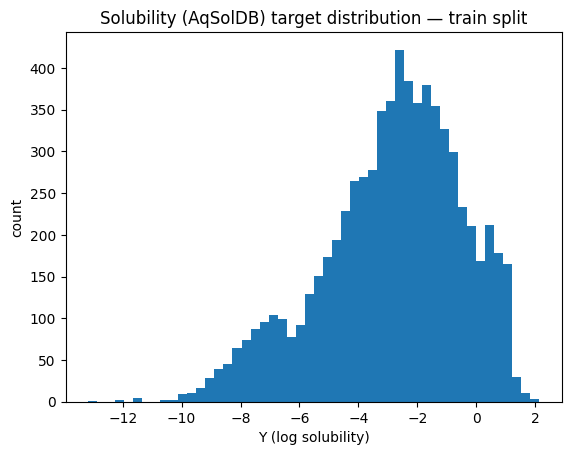

In [5]:
import matplotlib.pyplot as plt

print(solubility_split['train']['Y'].describe())

plt.hist(solubility_split['train']['Y'], bins=50)
plt.xlabel('Y (log solubility)')
plt.ylabel('count')
plt.title('Solubility (AqSolDB) target distribution — train split')
plt.show()

In [6]:
# Sanity check: any duplicate compounds?
train = solubility_split['train']
print("duplicate Drug_ID:", train['Drug_ID'].duplicated().sum())
print("duplicate SMILES (Drug):", train['Drug'].duplicated().sum())

duplicate Drug_ID: 37
duplicate SMILES (Drug): 0
